# 01. Data Collection

Pull NFLX and peer daily bars from Yahoo Finance, cache them locally, and validate them
before anything else touches them.

Run every cell top to bottom: **Shift+Enter** on each, or `Run → Run All Cells`.
Check the kernel picker in the top right says **Python (nflx)**.

## Setup

Make the project's `src/` package importable from inside `notebooks/`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import load_prices, load_many, closing_prices, validate_prices

print("project root:", ROOT)
print("ticker:", config.TICKER, "| peers:", config.PEERS)
print("range:", config.START, "->", config.END or "today")

project root: /Users/matthew/projects/netflix-stock-forecasting
ticker: NFLX | peers: ['DIS', 'WBD', 'AMZN', 'SPY']
range: 2015-01-01 -> today


## Load NFLX

First call downloads and caches to `data/raw/NFLX.csv`. Every later call reads the cache.

In [2]:
nflx = load_prices(config.TICKER)
print(nflx.shape)
nflx.head()

(2937, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,4.915143,5.033143,4.873143,4.984857,134750000
2015-01-05,4.925857,4.925857,4.714714,4.731143,181650000
2015-01-06,4.734714,4.764000,4.566143,4.650143,160377000
2015-01-07,4.734714,4.742143,4.627143,4.674286,98497000
2015-01-08,4.712000,4.783571,4.647857,4.778000,96019000


In [3]:
nflx.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-01,80.169998,82.129997,79.599998,80.809998,21164900
2026-09-02,80.550003,83.120003,80.300003,82.730003,22077800
2026-09-03,83.180000,83.599998,81.629997,82.669998,24006400
2026-09-04,82.169998,82.690002,78.230003,78.250000,40066200
2026-09-08,77.510002,77.730003,76.440002,76.559998,2320813


### A gotcha worth knowing

If you run this while the US market is open, the **final row is a partial session**. The
day is not finished, so its `Close` is just the last trade so far and its `Volume` is a
fraction of a full day. Training on it would teach the model from an incomplete bar.

The cell below flags it. Drop that row before modeling.

In [4]:
median_volume = nflx["Volume"].median()
last = nflx.iloc[-1]

print(f"last bar: {nflx.index[-1].date()}")
print(f"  volume {last['Volume']:>14,.0f}")
print(f"  median {median_volume:>14,.0f}")

if last["Volume"] < 0.4 * median_volume:
    print("\n-> Looks like a partial session. Excluding it.")
    nflx = nflx.iloc[:-1]
else:
    print("\n-> Full session. Keeping it.")

print("rows in use:", len(nflx))

last bar: 2026-09-08
  volume      2,320,813
  median     59,059,000

-> Looks like a partial session. Excluding it.
rows in use: 2936


## Validate

Gaps in a market calendar are normal: weekends and holidays. Missing values,
duplicate dates, out-of-order dates and non-positive prices are not.

In [5]:
for key, value in validate_prices(nflx, config.TICKER).items():
    print(f"{key:>22}: {value}")

                ticker: NFLX
                  rows: 2936
                 start: 2015-01-02
                   end: 2026-09-04
        missing_values: 0
       duplicate_dates: 0
   non_positive_prices: 0
    is_monotonic_dates: True
      largest_gap_days: 4
                    ok: True


## Load the peers

DIS and WBD are streaming competitors, AMZN a partial one, SPY the market benchmark.
These drive the correlation and risk sections in notebook 02.

In [6]:
frames = load_many()
closes = closing_prices(frames)

print(closes.shape)
closes.tail()

(2937, 5)


,NFLX,DIS,WBD,AMZN,SPY
Date,,,,,
2026-09-01,80.809998,106.220001,28.320000,254.919998,761.780029
2026-09-02,82.730003,107.980003,28.389999,254.979996,765.159973
2026-09-03,82.669998,107.160004,28.370001,258.899994,773.169983
2026-09-04,78.250000,105.309998,28.250000,258.510010,770.190002
2026-09-08,76.559998,104.320000,28.215000,256.589996,768.840027


In [7]:
# How much history does each ticker actually have?
for ticker, frame in frames.items():
    print(f"{ticker:>5}: {len(frame):>5} rows  "
          f"{frame.index.min().date()} -> {frame.index.max().date()}")

 NFLX:  2937 rows  2015-01-02 -> 2026-09-08
  DIS:  2937 rows  2015-01-02 -> 2026-09-08
  WBD:  2937 rows  2015-01-02 -> 2026-09-08
 AMZN:  2937 rows  2015-01-02 -> 2026-09-08
  SPY:  2937 rows  2015-01-02 -> 2026-09-08


## First look

One plot, purely to confirm the data is sane before notebook 02 does the real EDA.

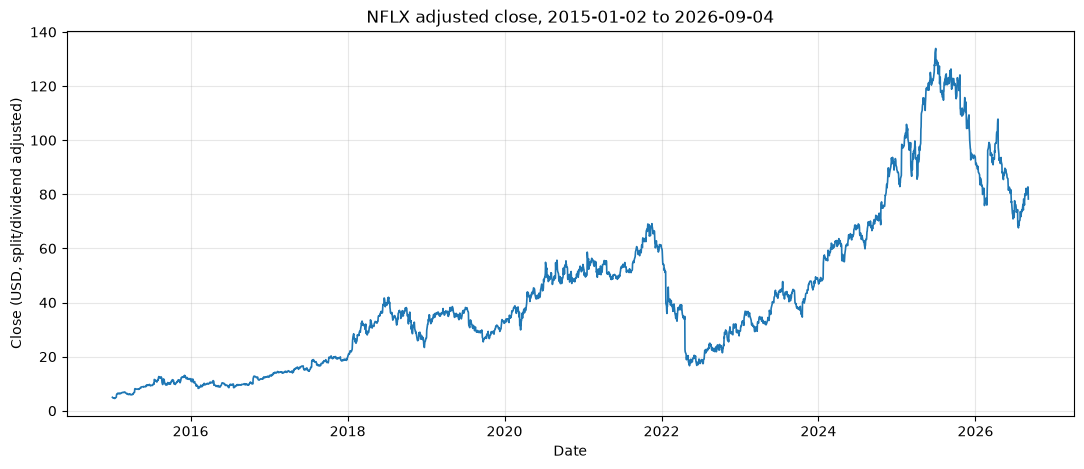

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(nflx.index, nflx["Close"], linewidth=1.2)
ax.set_title(f"{config.TICKER} adjusted close, {nflx.index.min().date()} to {nflx.index.max().date()}")
ax.set_xlabel("Date")
ax.set_ylabel("Close (USD, split/dividend adjusted)")
ax.grid(alpha=0.3)

config.ensure_dirs()
fig.savefig(config.FIGURES / "01_nflx_close.png", dpi=150, bbox_inches="tight")
plt.show()

## What this established

- NFLX daily bars load, cache, and pass validation.
- Peer tickers align on a shared date index.
- The current partial session is detected and excluded.
- Prices are split and dividend adjusted (`auto_adjust=True`), so returns computed from
  `Close` are correct without a separate `Adj Close` column.

**Next:** `02_eda_market_analysis.ipynb`, covering moving averages, daily return distribution,
peer correlation, and risk versus return.